In [19]:
import sys
import os
from dotenv import load_dotenv

current_dir = os.path.abspath('')
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

load_dotenv(os.path.join(parent_dir, '.env'))

True

In [20]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib

from sqlalchemy import text
from config import engine

In [21]:
def fetch() -> pd.DataFrame:
    query = """
        SELECT 
            dd.date AS order_date, 
            pr.is_muslim_fashion, oc.quantity
        FROM order_fact oc
        JOIN date_dimension dd ON dd.date_id = oc.date_id
        JOIN product_dimension pr ON pr.product_id = oc.product_id
        WHERE oc.status = 'SELESAI'
    """
    with engine.connect() as conn:
        df = pd.read_sql(text(query), conn)

    df["order_date"] = pd.to_datetime(df["order_date"])
    df = df[df["quantity"] > 0]
    df = df.groupby("order_date").agg({
        "quantity": "sum",
        "is_muslim_fashion": "max"
    }).reset_index()
    return df

In [22]:
df = fetch()

In [23]:
query = """
    SELECT 
        date AS order_date, days_name, month, is_weekend, 
        is_twin_date, is_payday, is_ramadhan
    FROM date_dimension
    WHERE date BETWEEN '2024-01-01' AND '2026-12-31'
"""
with engine.connect() as conn:
    df_date_prop = pd.read_sql(text(query), conn)
    
df_date_prop["order_date"] = pd.to_datetime(df_date_prop["order_date"])   
        
all_dates = pd.date_range(df.order_date.min(), df.order_date.max(), freq="D")

df = df.set_index("order_date")
df = df.reindex(all_dates)
df = df.reset_index().rename(columns={"index": "order_date"})

df = df.merge(df_date_prop, on="order_date", how="left")
df = df.fillna({
    "quantity": 0,
    "is_muslim_fashion": 0,
})

In [24]:
df["rolling_mean_3_qty"] = df["quantity"].rolling(window=3, min_periods=1, closed="left").mean()
df["rolling_mean_7_qty"] = df["quantity"].rolling(window=7, min_periods=1, closed="left").mean()
df["rolling_mean_14_qty"] = df["quantity"].rolling(window=14, min_periods=1, closed="left").mean()
df["rolling_mean_30_qty"] = df["quantity"].rolling(window=30, min_periods=1, closed="left").mean()

df["rolling_std_3_qty"] = df["quantity"].rolling(window=3, min_periods=1, closed="left").std()
df["rolling_std_7_qty"] = df["quantity"].rolling(window=7, min_periods=1, closed="left").std()

df["lag_1_qty"] = df["quantity"].shift(1)
df["lag_3_qty"] = df["quantity"].shift(3)
df["lag_7_qty"] = df["quantity"].shift(7)
df["lag_21_qty"] = df["quantity"].shift(21)
df["lag_28_qty"] = df["quantity"].shift(28)

df["lag_7_rolling_mean"] = df["rolling_mean_7_qty"].shift(7)
df["lag_14_rolling_mean"] = df["rolling_mean_14_qty"].shift(14)

df = df.dropna().reset_index(drop=True)

In [25]:
df["payday_weekend"] = df["is_payday"] * df["is_weekend"]
df["ramadhan_twin"] = df["is_ramadhan"] * df["is_twin_date"]
df["day_of_year"] = df["order_date"].dt.dayofyear
df["week_of_year"] = df["order_date"].dt.isocalendar().week.astype(int)

df["is_month_end"] = df["order_date"].dt.is_month_end.astype(int)
df["is_month_start"] = df["order_date"].dt.is_month_start.astype(int)


In [26]:
cat_cols = ["days_name", "month"]

for col in cat_cols:
    df[col] = df[col].astype("category")

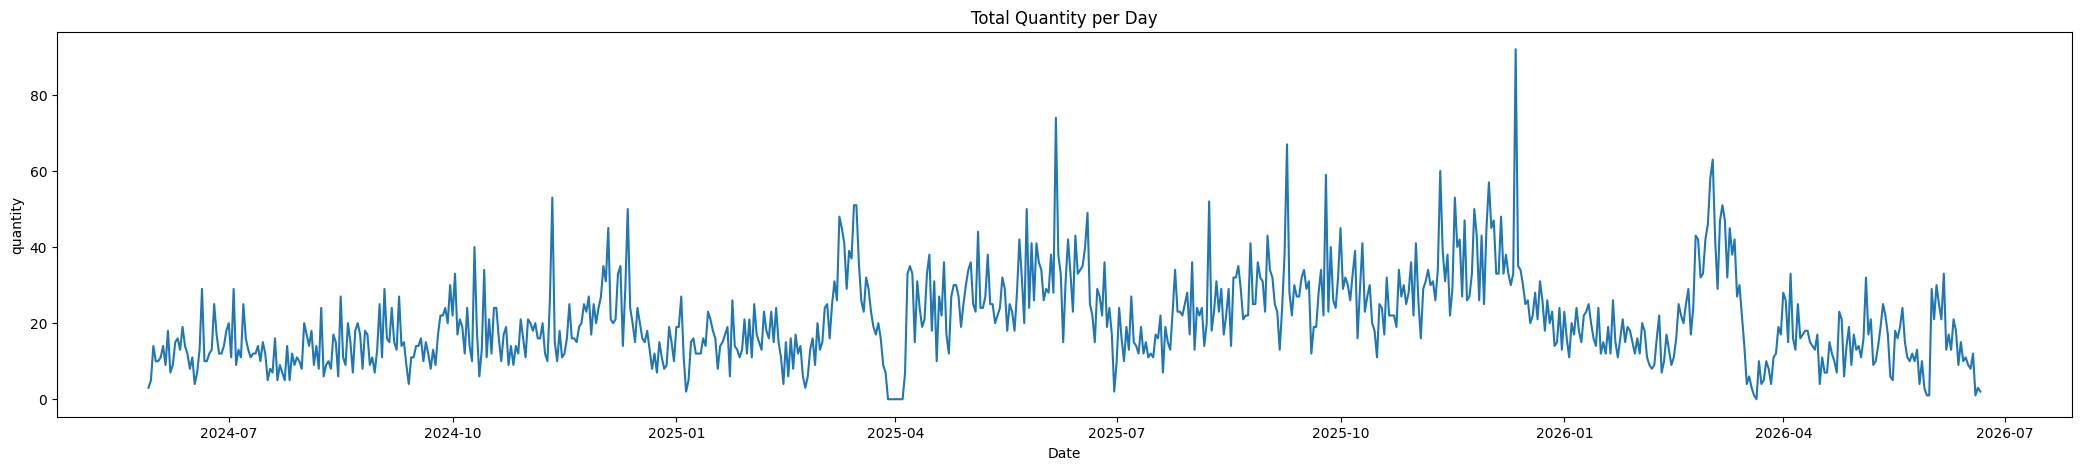

In [27]:
x_axis = df["order_date"]
y_axis = df["quantity"]

plt.figure(figsize=(26, 5))

plt.plot(x_axis, y_axis)

plt.title("Total Quantity per Day")
plt.xlabel("Date")
plt.ylabel("quantity")

plt.show()

count    754.000000
mean      20.850133
std       11.588568
min        0.000000
25%       13.000000
50%       19.000000
75%       27.000000
max       92.000000
Name: quantity, dtype: float64
Skewness: 1.15


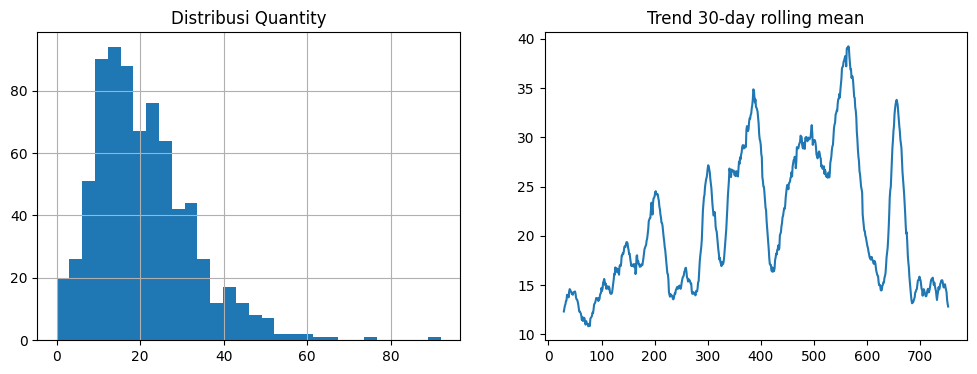

In [28]:
print(df["quantity"].describe())
print(f"Skewness: {df['quantity'].skew():.2f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df["quantity"].hist(bins=30)
plt.title("Distribusi Quantity")

plt.subplot(1, 2, 2)
df["quantity"].rolling(30).mean().plot()
plt.title("Trend 30-day rolling mean")
plt.show()

In [29]:
target = (df["quantity"])
features = df.drop(columns=[
    "order_date", 
    "quantity"
])

split_index = int(len(df) * 0.8)

X_train, X_test = features.iloc[:split_index], features.iloc[split_index:]
y_train, y_test = target.iloc[:split_index], target.iloc[split_index:]

# fixed_params = {
#     "n_estimators": 500,       
#     "learning_rate": 0.01,     
#     "subsample": 0.7,          
#     "colsample_bytree": 0.7,   
#     "reg_alpha": 1.5,      
#     "reg_lambda": 1.5,       
#     "random_state": 42,
#     "verbose": -1
# }

# fixed_params = {
#     "n_estimators": 500,       
#     "learning_rate": 0.01,   
#     "random_state": 42,
#     "subsample": 0.7,
#     "colsample_bytree": 0.7,
#     "verbose": -1
# }


fixed_params = {
    "n_estimators": 100,       
    "learning_rate": 0.1,   
    "random_state": 42,   
    "verbose": -1
}

model_base = lgb.LGBMRegressor(**fixed_params)

# param_grid = {
#     "num_leaves": [7, 10, 15], 
#     "max_depth": [3, 4, 5],     
#     "min_child_samples": [10, 15, 20] 
# }

param_grid = [
    {
        "max_depth": [3],
        "num_leaves": [5, 7],
        "min_child_samples": [10, 15, 20]
    },
    {
        "max_depth": [4, 5],
        "num_leaves": [7, 10, 15],
        "min_child_samples": [10, 15, 20]
    }
]

cat_cols = ["days_name", "month"]
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
    X_train[col] = X_train[col].astype("category")
    X_test[col] = pd.Categorical(X_test[col], categories=X_train[col].cat.categories)
    
tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=model_base,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=False
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

best_model = lgb.LGBMRegressor(**fixed_params, **best_params)
best_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val), (X_train, y_train)],
    eval_metric=["rmse", "mae"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=15)
    ]
)

best_n_estimators = best_model.best_iteration_ or fixed_params["n_estimators"]
best_model = lgb.LGBMRegressor(**{**fixed_params, **best_params, "n_estimators": best_n_estimators})
best_model.fit(
    X_train, y_train,
    eval_metric=["rmse", "mae"],
    callbacks=[
        lgb.log_evaluation(5)
        ]
)

y_pred = np.maximum(best_model.predict(X_test), 0)
train_pred = np.maximum(best_model.predict(X_train), 0)

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[34]	valid_0's rmse: 10.4733	valid_0's l1: 7.31405	valid_0's l2: 109.69	valid_1's rmse: 6.69574	valid_1's l1: 4.86639	valid_1's l2: 44.833


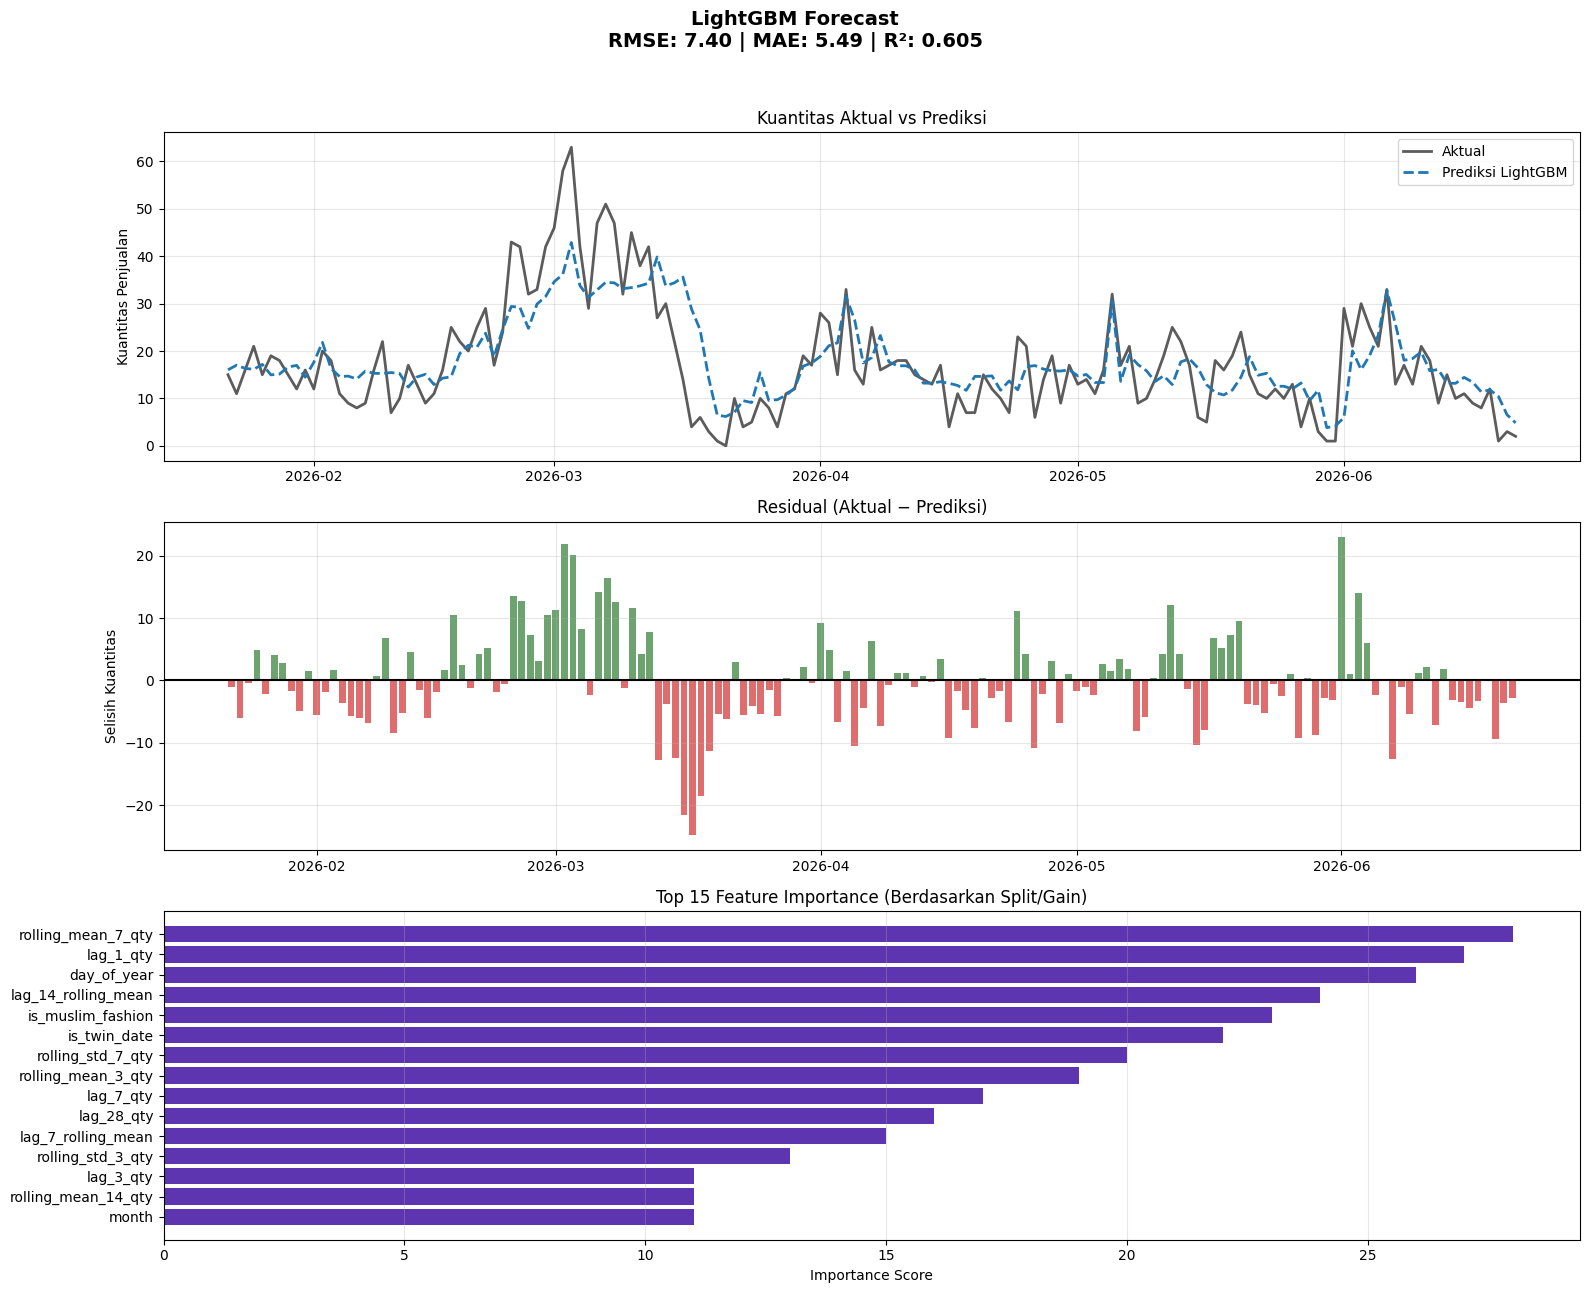

In [30]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

test_dates = df["order_date"].iloc[split_index : split_index + len(y_test)].values

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle(f"LightGBM Forecast\nRMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}", 
             fontsize=14, fontweight="bold", y=0.92)

axes[0].plot(test_dates, y_test.values, label="Aktual", color="#333333", linewidth=2, alpha=0.8)
axes[0].plot(test_dates, y_pred, label="Prediksi LightGBM", color="#1f77b4", linewidth=2, linestyle="--")
axes[0].set_title("Kuantitas Aktual vs Prediksi", fontsize=12)
axes[0].set_ylabel("Kuantitas Penjualan")
axes[0].legend(loc="upper right", fontsize=10)
axes[0].grid(True, alpha=0.3)

residuals = y_test.values - y_pred
colors = ["#2E7D32" if r >= 0 else "#D32F2F" for r in residuals]

axes[1].bar(test_dates, residuals, color=colors, alpha=0.7, width=0.8)
axes[1].axhline(0, color="black", linewidth=1.5)
axes[1].set_title("Residual (Aktual − Prediksi)", fontsize=12)
axes[1].set_ylabel("Selisih Kuantitas")
axes[1].grid(True, alpha=0.3)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

axes[2].barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#5E35B1")
axes[2].set_title("Top 15 Feature Importance (Berdasarkan Split/Gain)", fontsize=12)
axes[2].set_xlabel("Importance Score")
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [31]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Batas Error Prediksi (RMSE): {rmse}")
print(f"Batas Error Prediksi TRAIN (RMSE): {train_rmse}")

Batas Error Prediksi (RMSE): 7.401023007325836
Batas Error Prediksi TRAIN (RMSE): 5.800477976833763


In [32]:
train_mae = mean_absolute_error(y_train, train_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Batas Error Prediksi TRAIN (MAE): {train_mae}")
print(f"Batas Error Prediksi (MAE): {mae}")

Batas Error Prediksi TRAIN (MAE): 4.5218234773809405
Batas Error Prediksi (MAE): 5.494692422160764


In [33]:
train_r2 = r2_score(y_train, train_pred)
r2 = r2_score(y_test, y_pred)
print(f"R² Score (TRAIN): {train_r2}")
print(f"R² Score: {r2}")

R² Score (TRAIN): 0.7409730339466605
R² Score: 0.6046342441953896


In [34]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   is_muslim_fashion    754 non-null    float64 
 1   days_name            754 non-null    category
 2   month                754 non-null    category
 3   is_weekend           754 non-null    int64   
 4   is_twin_date         754 non-null    int64   
 5   is_payday            754 non-null    int64   
 6   is_ramadhan          754 non-null    int64   
 7   rolling_mean_3_qty   754 non-null    float64 
 8   rolling_mean_7_qty   754 non-null    float64 
 9   rolling_mean_14_qty  754 non-null    float64 
 10  rolling_mean_30_qty  754 non-null    float64 
 11  rolling_std_3_qty    754 non-null    float64 
 12  rolling_std_7_qty    754 non-null    float64 
 13  lag_1_qty            754 non-null    float64 
 14  lag_3_qty            754 non-null    float64 
 15  lag_7_qty            75

In [35]:
features.tail(20)

,is_muslim_fashion,days_name,month,is_weekend,is_twin_date,is_payday,is_ramadhan,rolling_mean_3_qty,rolling_mean_7_qty,rolling_mean_14_qty,...,lag_21_qty,lag_28_qty,lag_7_rolling_mean,lag_14_rolling_mean,payday_weekend,ramadhan_twin,day_of_year,week_of_year,is_month_end,is_month_start
734,1.0,Tuesday,June,0,0,0,0,10.333333,8.714286,11.571429,...,25.0,32.0,14.428571,16.500000,0,0,153,23,0,0
735,0.0,Wednesday,June,0,0,0,0,17.000000,9.857143,11.714286,...,22.0,17.0,13.571429,15.571429,0,0,154,23,0,0
736,0.0,Thursday,June,0,0,0,0,26.666667,13.571429,12.142857,...,17.0,21.0,10.714286,16.071429,0,0,155,23,0,0
737,1.0,Friday,June,0,0,0,0,25.333333,15.714286,12.857143,...,6.0,9.0,10.000000,15.642857,0,0,156,23,0,0
738,1.0,Saturday,June,1,1,0,0,25.333333,18.285714,13.571429,...,5.0,10.0,8.857143,15.785714,0,0,157,23,0,0
739,1.0,Sunday,June,1,0,0,0,26.333333,22.857143,15.214286,...,18.0,14.0,7.571429,15.785714,0,0,158,23,0,0
740,0.0,Monday,June,0,0,0,0,22.333333,24.571429,15.285714,...,16.0,19.0,6.000000,15.642857,0,0,159,24,0,0
741,0.0,Tuesday,June,0,0,0,0,21.000000,22.857143,15.785714,...,19.0,25.0,8.714286,15.000000,0,0,160,24,0,0
742,1.0,Wednesday,June,0,0,0,0,14.333333,21.714286,15.785714,...,24.0,22.0,9.857143,14.142857,0,0,161,24,0,0
743,1.0,Thursday,June,0,0,0,0,17.000000,20.428571,17.000000,...,15.0,17.0,13.571429,12.857143,0,0,162,24,0,0


In [36]:
# joblib.dump(best_model, "saved_models/champion_model.pkl")